In [7]:
import os
import sys
import random
import ast
import shap
sys.path.append('../../')
import pandas as pd
import numpy as np
import pyabf
import tsfel
import hdbscan
import seaborn as sns
import umap  
import umap.parametric_umap
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from preprocessing.preprocess import *
from sklearn.feature_selection import VarianceThreshold, f_classif
from models.clustering import *
from models.dsc import *
import xgboost as xgb
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import LabelEncoder

# Feature extraction process. blockades.pkl created.

In [2]:
pet_folder_path = "/mnt/vnas/ml4nanopore_data/raw/PET_TE/output"
dataframes = []

for file_name in os.listdir(pet_folder_path):
    if file_name.endswith(".csv"):
        file_path = os.path.join(pet_folder_path, file_name)
        df = pd.read_csv(file_path, sep="\t")
        df["file"] = file_name[:-18]
        dataframes.append(df)

pet_meta = pd.concat(dataframes, ignore_index=True)

In [3]:
pet_meta

,EventId,idxstart,idxend,risetime,falltime,length,Irms,Io,I/Io,Imean,Isig,isBL?,file
0,0,881,2253,0,0,1372,"111,6103102173639","290,27291141691126","0,3845012945664123","110,7649989081974","13,71044724592276",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-2 120m...
1,1,5026,5028,0,0,2,"238,6382401886214","290,27291141691126","0,8221168107756072","238,6067562699318","3,8762794872827477",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-2 120m...
2,2,5072,5073,0,0,1,"237,9522726607232","290,27291141691126","0,8197536294351583","237,9302833294496","3,234863083809614",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-2 120m...
3,3,5234,5236,0,0,2,"244,60535813200894","290,27291141691126","0,8426737339630317","244,59328748006374","2,430009585010856",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-2 120m...
4,4,5476,5487,0,0,11,"232,69060868812755","290,27291141691126","0,8016270190431936","232,57444869540632","7,3515430814982485",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-2 120m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
773768,153495,342992307,342992313,0,0,6,"63,89496688295583","235,9212927484072","0,27083170890850927","59,99973475866552","21,968127409130854",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-8-32-1...
773769,153496,342994456,342994457,0,0,1,"192,8176836156648","235,9212927484072","0,8172966558863797","192,81767621962354","0,05340575845912099",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-8-32-1...
773770,153497,342997173,342997175,0,0,2,"108,10485511241788","235,9212927484072","0,4582242401821009","107,21841793507338","13,81559098905285",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-8-32-1...
773771,153498,342998744,342998745,0,0,1,"190,76533168536258","235,9212927484072","0,8085973481367782","190,7424810337834","2,952575503382832",False,20210304 AeL R220S 4M KCl PEG 1k5-12-28-8-32-1...


In [ ]:
# pet_meta.to_csv("/home/rushang_phira/src/data/all_pet.csv", index=False)

In [3]:
proteins = {
    "histones": pd.read_csv("/home/rushang_phira/src/data/all_blockades.csv"),
    "pet": pet_meta,
    "mdr_aplysia": pd.read_csv("/mnt/vnas/ml4nanopore_data/processed/3_full_df_blockades_mdr1_14_09_kurt_skew_min_incl.csv").dropna().reset_index(drop=True),
    "ladder_1": pd.read_csv("/home/rushang_phira/src/data/Peptide Ladders/new_outputs_L1/2020-03-13 wtAeL L1AS4 AS5 AS6 AS7 AS8 AS9 AS10.abf_currentlevels.csv", sep="\t"),
    "ladder_2": pd.read_csv("/home/rushang_phira/src/data/Peptide Ladders/new_outputs_L2/20200309 wtAeL 4M KCl 1µL 1X L2AS4_AS5_AS6_AS7_AS8_AS9_AS10.abf_currentlevels.csv", sep="\t"),
    "ladder_3": pd.read_csv("/mnt/vnas/ml4nanopore_data/raw/PeptideLadders/Ladder3/2020-05-14 wtAeL L3AS4 AS5 AS6 AS7 AS8 AS9 AS10-s1.abf_currentlevels.csv", sep="\t"),
    "ladder_4": pd.read_csv("/home/rushang_phira/src/data/Peptide Ladders/new_outputs_L4/2020-05-15 wtAeL L4AS4 AS5 AS6 AS7 AS8 AS9 AS10-s1.abf_currentlevels.csv", sep="\t"),
    "ladder_5": pd.read_csv("/home/rushang_phira/src/data/Peptide Ladders/new_outputs_L5/2020-05-18 wtAeL L5AS4 AS5 AS6 AS7 AS8 AS9 AS10-s1.abf_currentlevels.csv", sep="\t"),
    "ladder_6": pd.read_csv("/home/rushang_phira/src/data/Peptide Ladders/new_outputs_L6/2020-05-19 wtAeL L6AS4 AS5 AS6 AS7 AS8 AS9 AS10-s1.abf_currentlevels.csv", sep="\t")
    }

In [ ]:
for name, df in proteins.items():
    if name[0:6] == "ladder":
        # & (df['I/Io'] < 0.5) & (df['I/Io'] > 0.35)
        # (df['length'] > 1000) & (df['length'] < 10000)
        df[['Irms', 'Io', 'I/Io', 'Imean', 'Isig']] = df[['Irms', 'Io', 'I/Io', 'Imean', 'Isig']].replace({',': '.'}, regex=True).astype(float)
        df = df[(df['EventId'] != 0) & (df['I/Io'] < 0.72) & (df['I/Io'] > 0.35)].reset_index(drop=True)
        proteins[name] = df

    if name == "histones":
        df = df[(df['EventId'] != 0) & (df['I/Io'] < 0.56) & (df['I/Io'] > 0.46)]
        df = df.reset_index(drop=True)
        proteins[name] = df

    if name == "pet":
        df[['Io', 'I/Io']] = df[['Io', 'I/Io']].replace({',': '.'}, regex=True).astype(float)
        df = df[df['EventId'] != 0]
        df = df.reset_index(drop=True)
        proteins[name] = df

    if name == "mdr_aplysia":
        df = df.dropna()
        df = df.rename(columns={'species': 'label', 'idx_start_time': 'idxstart', 'idx_end_time': 'idxend', "dwelltime": "length"})
        df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "...1"]).reset_index(drop=True)
        proteins[name] = df
    
'''I filter out the dataframe to only include the middle 90% of the I/Io and length values'''   
for name, df in proteins.items():
    if 'length' in df:
        q5, q95 = np.percentile(df["length"], [5, 95])
        proteins[name] = df[(df["length"] >= q5) & (df["length"] <= q95)] 
    if 'I/Io' in df:  # Ensure 'length' column exists
        q5, q95 = np.percentile(df["I/Io"], [5, 95])
        proteins[name] = df[(df["I/Io"] >= q5) & (df["I/Io"] <= q95)]

In [123]:
print("Median length of PET: ", np.median(pet_meta["length"]), "\nMean length of PET: ", np.mean(pet_meta["length"]))

Median length of PET:  2.0 
Mean length of PET:  755.954645613119


#### PET data has much lower lengths than the others. It has also a lot of very high outlier lengths

In [ ]:
# '''Code to read MDR1 and Applysia metadata from CSV files and append'''
# folder_path = '/mnt/vnas/ml4nanopore_data/raw/priyanka_data/metadata'
# all_data = [] 

# for filename in os.listdir(folder_path):
#     file_path = os.path.join(folder_path, filename)
#     try:
#         # Read the file into a DataFrame
#         df = pd.read_csv(file_path, delimiter='\t', header=None, names=['Date', 'Base', 'Dwell Time', 'I/Io', 'Noise']).dropna()
        
#         # Filter rows where 'Dwell Time' > 20
#         filtered_df = df[df['Dwell Time'] > 250]
        
#         # Add a 'label' column based on filename
#         if "MDR1" in filename:
#             filtered_df['label'] = 0
#         else:
#             filtered_df['label'] = 1
        
#         # Append filtered_df to the list of all DataFrames
#         all_data.append(filtered_df)
    
#     except Exception as e:
#         print(f"Error processing file {filename}: {e}")

# # Concatenate all DataFrames in the list into a single DataFrame
# final_df = pd.concat(all_data, ignore_index=True)


In [10]:
np.median(proteins["pet"]["length"])

2.0

In [8]:
histones_currents, histones_base = [], proteins["histones"]["Io"].mean()
pet_currents, pets_base = [], proteins["pet"]["Io"].mean()
mdr_currents, mdr_base = [], -130.014
aplysia_currents, aplysia_base = [], -130.014
ladder_1_base, ladder_2_base, ladder_3_base, ladder_4_base, ladder_5_base, ladder_6_base = np.mean([int(i) for i in proteins["ladder_1"]["Io"]]), np.mean([int(i) for i in proteins["ladder_2"]["Io"]]), np.mean([int(i) for i in proteins["ladder_3"]["Io"]]), np.mean([int(i) for i in proteins["ladder_4"]["Io"]]), np.mean([int(i) for i in proteins["ladder_5"]["Io"]]), np.mean([int(i) for i in proteins["ladder_6"]["Io"]])

ladder_currents = {
    "ladder_1": [],
    "ladder_2": [],
    "ladder_3": [],
    "ladder_4": [],
    "ladder_5": [],
    "ladder_6": []
}

ladder_abfs = {
    "ladder_1": pyabf.ABF("/mnt/vnas/ml4nanopore_data/raw/PeptideLadders/Ladder1/2020-03-13 wtAeL L1AS4 AS5 AS6 AS7 AS8 AS9 AS10.abf").data[0],
    "ladder_2": pyabf.ABF("/mnt/vnas/ml4nanopore_data/raw/PeptideLadders/Ladder2/20200309 wtAeL 4M KCl 1µL 1X L2AS4_AS5_AS6_AS7_AS8_AS9_AS10.abf").data[0],
    "ladder_3": pyabf.ABF("/mnt/vnas/ml4nanopore_data/raw/PeptideLadders/Ladder3/2020-05-14 wtAeL L3AS4 AS5 AS6 AS7 AS8 AS9 AS10-s1.abf").data[0],
    "ladder_4": pyabf.ABF("/mnt/vnas/ml4nanopore_data/raw/PeptideLadders/Ladder4/2020-05-15 wtAeL L4AS4 AS5 AS6 AS7 AS8 AS9 AS10-s1.abf").data[0],
    "ladder_5": pyabf.ABF("/mnt/vnas/ml4nanopore_data/raw/PeptideLadders/Ladder5/2020-05-18 wtAeL L5AS4 AS5 AS6 AS7 AS8 AS9 AS10-s1.abf").data[0],
    "ladder_6": pyabf.ABF("/mnt/vnas/ml4nanopore_data/raw/PeptideLadders/Ladder6/2020-05-19 wtAeL L6AS4 AS5 AS6 AS7 AS8 AS9 AS10-s1.abf").data[0]
}

def load_abf_files(folder_path):
    abf_files = {}
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        abf_files[filename] = pyabf.ABF(file_path)
    return abf_files

aplysia_folder_path = "/mnt/vnas/ml4nanopore_data/raw/priyanka_data/aplysia_peptides"
mdr_folder_path = "/mnt/vnas/ml4nanopore_data/raw/priyanka_data/MDRprotein"

aplysia_abf_files = load_abf_files(aplysia_folder_path)
mdr_abf_files = load_abf_files(mdr_folder_path)

for index, row in proteins["mdr_aplysia"].iterrows():
    if row['label'] == 0:  # Check aplysia folder
        abf_filename = row['File']
        idxstart = int(row['idxstart'])
        idxend = int(row['idxend'])
        abf = aplysia_abf_files[abf_filename]
        currents = abf.data[0][idxstart:idxend]
        aplysia_currents.append(currents)

    elif row['label'] == 1:  # Check MDR1 folder
        abf_filename = row['File']
        idxstart = int(row['idxstart'])
        idxend = int(row['idxend'])
        abf = mdr_abf_files[abf_filename]
        currents = abf.data[0][idxstart:idxend]
        mdr_currents.append(currents)

abf_data_dict = {}
for _, row in proteins["histones"].iterrows():
    abf_file = row["file"] + ".abf"
    if abf_file not in abf_data_dict:
        abf_data_dict[abf_file] = pyabf.ABF(abf_file).data[0]

histones_currents = []
for n, row in proteins["histones"].iterrows():
    abf_file = row["file"] + ".abf"
    abf_data = abf_data_dict[abf_file]
    start_idx = row["idxstart"]
    end_idx = row["idxend"]
    current_data = abf_data[start_idx:end_idx]
    histones_currents.append(current_data)

pet_abf_path = "/mnt/vnas/ml4nanopore_data/raw/PET_TE"
pet_abf_files = {}

for file_name in pet_meta["file"].unique():
    file_path = os.path.join(pet_abf_path, file_name)
    pet_abf_files[file_name] = pyabf.ABF(file_path)

for index, row in proteins["pet"].iterrows():
    abf_filename = row['file']
    idxstart = int(row['idxstart'])
    idxend = int(row['idxend'])
    abf = pet_abf_files[abf_filename]
    currents = abf.data[0][idxstart:idxend]
    pet_currents.append(currents)

for ladder_name, df in proteins.items():
    if ladder_name.startswith("ladder"):
        for n, row in df.iterrows():
            abf_data = ladder_abfs[ladder_name]
            start_idx = df["idxstart"][n]
            end_idx = df["idxend"][n]
            current_data = abf_data[start_idx:end_idx]
            ladder_currents[ladder_name].append(current_data)

In [ ]:
def extract_features(blockades, I0):
    amplitudes, sds, dwell_times, features = [], [], [], []

    for blockade in blockades:
        if len(blockade) < 3:  # Skip shorter blockades. Was getting some errors during runtime, probably shorter blockades
            continue  
        mean_I_blockade = np.mean(blockade)  # average
        delta_I = I0 - mean_I_blockade  # amplitude
        sd = np.std(blockade)  # SD
        dwell_time = len(blockade) # Doing length again
        
        amplitudes.append(delta_I)
        sds.append(sd)
        dwell_times.append(dwell_time)
        features.append([sd, dwell_time])

    return amplitudes, sds, dwell_times, np.array(features)

blockade_data = {
    "histones": (histones_currents, histones_base),
    "pet": (pet_currents, pets_base),
    "mdr": (mdr_currents, mdr_base),
    "aplysia": (aplysia_currents, aplysia_base),
    "ladder_1": (ladder_currents["ladder_1"], ladder_1_base),
    "ladder_2": (ladder_currents["ladder_2"], ladder_2_base),
    "ladder_3": (ladder_currents["ladder_3"], ladder_3_base),
    "ladder_4": (ladder_currents["ladder_4"], ladder_4_base),
    "ladder_5": (ladder_currents["ladder_5"], ladder_5_base),
    "ladder_6": (ladder_currents["ladder_6"], ladder_6_base),
}

features = {}
for protein, (currents, baseline) in blockade_data.items():
    features[protein] = extract_features(currents, baseline)

import plotly.express as px
import pandas as pd

# Prepare data for Plotly (creating a DataFrame from your features dictionary)
data = []

# Loop through each protein and add its features to the data list
for idx, (protein, (deltas, sds, dwell_times, feature)) in enumerate(features.items()):
    # Create a DataFrame for the current protein and its deltas and sds
    df = pd.DataFrame({'ΔI (pA)': deltas, 'SD (pA)': sds, 'Protein': [protein]*len(deltas)})
    
    # Append the current protein's data
    data.append(df)

# Concatenate all protein data into one DataFrame
df_all = pd.concat(data)

# Create an interactive scatter plot with Plotly
fig = px.scatter(df_all, x="ΔI (pA)", y="SD (pA)", color="Protein", 
                 title="Blockade Event Analysis: ΔI vs. SD for Different Proteins",
                 labels={"ΔI (pA)": "ΔI (Current Amplitude) [pA]", "SD (pA)": "SD (Standard Deviation) [pA]"},
                 color_discrete_sequence=px.colors.qualitative.Set1)

# Add the mean values as star markers for each protein
for idx, (protein, (deltas, sds, dwell_times, feature)) in enumerate(features.items()):
    mean_delta = np.mean(deltas)
    mean_sd = np.mean(sds)
    
    # Add the mean point to the figure
    fig.add_scatter(x=[mean_delta], y=[mean_sd], mode='markers+text', 
                    text=[f'{protein} Mean'], textposition="top center", 
                    marker=dict(color=px.colors.qualitative.Set3[idx], size=22, symbol='star'))


fig.update_layout(
    xaxis_title="ΔI (Current Amplitude) [pA]",
    yaxis_title="SD (Standard Deviation) [pA]",
    template="plotly_white",
    hovermode="closest",
    showlegend=True
)

# Show the interactive plot
fig.show()

In [ ]:
# import pickle

# with open('/home/rushang_phira/src/data/complete_feature_sets/all_blockades.pkl', 'wb') as f:
#     pickle.dump(currents_dict, f)

In [13]:
with open('/home/rushang_phira/src/data/complete_feature_sets/all_blockades.pkl', 'rb') as f:
    check = pickle.load(f)

In [ ]:
currents_dict = {
    'mdr_currents': mdr_currents,
    'histones_currents': histones_currents,
    'pet_currents': pet_currents,
    "ladder_1": ladder_currents["ladder_1"],
    "ladder_2": ladder_currents["ladder_2"],
    "ladder_3": ladder_currents["ladder_3"],
    "ladder_4": ladder_currents["ladder_4"],
    "ladder_5": ladder_currents["ladder_5"],
    "ladder_6": ladder_currents["ladder_6"]
}

all_features = []

for key, currents in currents_dict.items():
    feature_list = []
    feature_names = None

    for ts in currents:
        result = catch22_all(ts)
        feature_values = result['values']
        if feature_names is None:
            feature_names = result['names']
        feature_list.append(feature_values)
    
    features_df = pd.DataFrame(feature_list, columns=feature_names)

    features_df['label'] = key

    all_features.append(features_df)

catch_22_features = pd.concat(all_features, ignore_index=True)

catch_22_features.to_csv("/home/rushang_phira/src/data/complete_feature_sets/catch22.csv", index=False)

# Clustering with TSFEL Pool

#### this picks up the results of the feature extraction python files

In [8]:
final_feature_df = pd.read_csv("/home/rushang_phira/src/data/complete_feature_sets/tsfel.csv")

In [35]:
check = pd.read_csv("/home/rushang_phira/src/data/complete_feature_sets/tsfel.csv")

In [76]:
final_feature_df

,label,length,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,mdr_currents,67,1.0,0.0,0.0,0.0,3197.741699,2.200244e+05,3.611339,-0.003607,...,0.395372,0.395372,0.525304,0.987542,1.263877,1.541920,1.820992,2.078951,NaN,118.458778
1,mdr_currents,79,1.0,0.0,0.0,1.0,1799.591064,1.251785e+05,3.462337,-0.152510,...,0.198515,0.233173,0.495554,0.987544,1.298479,1.606396,1.935156,2.256846,NaN,110.787529
2,mdr_currents,42,1.0,0.0,0.0,0.0,2206.341553,1.696372e+05,5.536484,0.052848,...,0.367649,0.367649,0.901741,0.954946,1.220007,1.523372,1.828869,2.077102,NaN,117.600792
3,mdr_currents,78,1.0,0.0,0.0,1.0,9151.378906,1.075209e+06,1.346737,-0.019024,...,0.429055,0.721865,0.958225,1.260729,1.827678,2.364151,2.882151,3.411288,NaN,126.075089
4,mdr_currents,42,1.0,0.0,0.0,0.0,2248.834229,1.694375e+05,5.346531,-0.083514,...,0.367649,0.367649,0.726193,0.718718,0.815168,0.913961,1.015018,1.118188,NaN,115.777588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208014,ladder_6,1561,1.0,0.0,0.0,1.0,-77288.703125,3.891310e+06,0.911415,0.007602,...,0.632412,0.753281,1.304068,1.188168,1.707124,2.266037,2.866467,3.504536,NaN,62.140766
208015,ladder_6,176,1.0,0.0,0.0,1.0,-8614.812500,4.239585e+05,0.906041,-0.002790,...,0.617081,0.766543,1.147123,1.193685,1.709077,2.247609,2.767726,3.269695,NaN,55.548096
208016,ladder_6,1345,1.0,0.0,0.0,1.0,-65884.812500,3.291198e+06,1.059569,0.006167,...,0.515674,0.731928,1.224931,1.184204,1.694744,2.225450,2.781835,3.355580,NaN,60.829380
208017,ladder_6,411,1.0,0.0,0.0,1.0,-20121.826172,1.006913e+06,1.101208,-0.013383,...,0.327050,0.438142,1.034989,1.180423,1.691626,2.221772,2.757098,3.329129,NaN,58.886719


#### For tsfresh only

In [28]:

feature_names = final_feature_df.drop(columns="label").columns.tolist()

In [ ]:
final_feature_df = final_feature_df.loc[:, ~final_feature_df.columns.str.contains('c3|value__quantile|value__agg_linear_trend|large_standard_deviation|change_quantiles')]
to_drop = ['length', 'value__standard_deviation', 'value__mean_second_derivative_central', 'value__linear_trend__attr_"intercept"', "length", "value__maximum", "value__minimum", 'value__variance_larger_than_standard_deviation', "value__median",  "value__mean", 'value__root_mean_square', 'value__standard_deviation', 'value__variance']
final_feature_df = final_feature_df.drop(columns=to_drop)

X = final_feature_df.drop(columns=['label']).values
y = final_feature_df['label'].values

feature_names = final_feature_df.drop(columns="label").columns.tolist()

#### Quick Preprocessing - Excerpt from preprocessing.py

In [10]:
'''Dropping features with greater than 50% NaN values'''
nan_threshold = 0.5 * len(final_feature_df)
final_feature_df.replace([np.inf, -np.inf], np.nan, inplace=True)

final_feature_df = final_feature_df.dropna(axis=1, thresh=nan_threshold)

'''Dropping features with variance lower than 0,1'''
numeric_features = final_feature_df.select_dtypes(include=['number'])
selector = VarianceThreshold(threshold=0.001)
reduced_features = selector.fit_transform(numeric_features)
retained_columns = numeric_features.columns[selector.get_support()]
final_feature_df = final_feature_df[retained_columns.tolist() + ['label']]  # Keep label

'''Filling remaining NaNs with median of that feature'''
final_feature_df.loc[:, final_feature_df.columns != 'label'] = final_feature_df.loc[:, final_feature_df.columns != 'label'].fillna(final_feature_df.median(numeric_only=True))
final_feature_df = final_feature_df.dropna()
'''Going by label and removing 10% of outliers using IsolationForest. Checking if I can make the clusters more prominent'''
from sklearn.ensemble import IsolationForest

def remove_outliers_by_label(df, label_column, contamination=0.3):
    cleaned_df = pd.DataFrame()  # To store the cleaned data
    
    # Iterate through each unique label
    for label in df[label_column].unique():
        # Filter the rows corresponding to the current label
        subset = df[df[label_column] == label]
        
        # Apply Isolation Forest for outlier detection
        iso_forest = IsolationForest(contamination=contamination)
        outliers = iso_forest.fit_predict(subset.drop(columns=[label_column]))  # Drop the label column
        
        # Outliers are labeled as -1, keep only the rows where outlier is 1 (inliers)
        subset_cleaned = subset[outliers == 1]
        
        # Append the cleaned subset to the result dataframe
        cleaned_df = pd.concat([cleaned_df, subset_cleaned], ignore_index=True)
    
    return cleaned_df

# Apply the function to remove outliers
final_feature_df = remove_outliers_by_label(final_feature_df, label_column='label', contamination=0.3)

'''For the purpose of clustering, I unite all Peptides Ladders to a single label'''
final_feature_df["label"] = [col if 'ladder' not in col else 'ladder' for col in final_feature_df["label"]]
final_feature_df = final_feature_df.loc[:, ~final_feature_df.columns.str.contains('MFCC')]
final_feature_df = final_feature_df.dropna()

### just tsfresh

In [ ]:
final_feature_df = final_feature_df.loc[:, ~final_feature_df.columns.str.contains('c3|value__quantile|value__agg_linear_trend|large_standard_deviation|change_quantiles|value__cwt_coefficients')]
to_drop = ['length', 'value__standard_deviation', 'value__mean_second_derivative_central', 'value__linear_trend__attr_"intercept"', "length", "value__maximum", "value__minimum", 'value__variance_larger_than_standard_deviation', "value__median", "value__mean", 'value__root_mean_square', 'value__standard_deviation', 'value__variance']
to_drop = ['EventId', 'length', 'idxstart', 'idxend', 'risetime', 'value__mean_abs_change', 'value__standard_deviation', 'value__mean_second_derivative_central', 'value__linear_trend__attr_"intercept"', 'falltime', "I/Io", "Io", "Irms", "length", "value__maximum", "value__minimum", "log_length", 'value__variance_larger_than_standard_deviation', "value__median", 'value__root_mean_square', 'value__standard_deviation', 'value__variance', 'Imean', 'Isig', 'isBL?', 'value__count_above__t_0']

if 'value__mean' in final_feature_df.columns:
    correlations = final_feature_df.drop(columns=['final_label']).corr()['value__mean'].abs()
    high_corr_features = correlations[correlations > 0.65].index.tolist()
    high_corr_features = [f for f in high_corr_features if f != 'value__mean']
    to_drop.extend(high_corr_features)
    print(f"Added {len(high_corr_features)} mean-correlated features to drop")
cleaned_data = final_feature_df.drop(columns=['value__mean'] + high_corr_features + to_drop)

X = final_feature_df.drop(columns=['label']).values
y = final_feature_df['label'].values

feature_names = final_feature_df.drop(columns="label").columns.tolist()

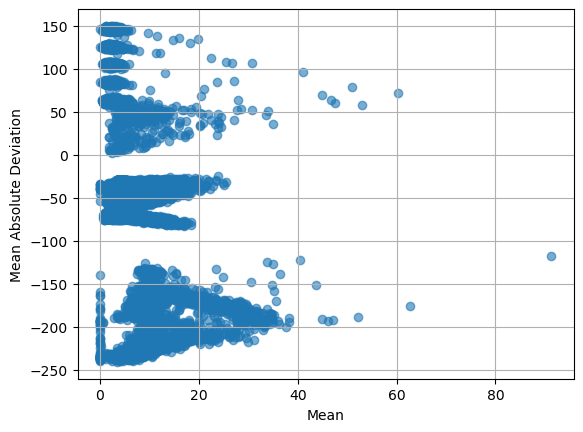

In [5]:
import matplotlib.pyplot as plt
plt.scatter(final_feature_df["0_Mean absolute deviation"], final_feature_df["0_Mean"], alpha=0.6)
plt.xlabel("Mean")
plt.ylabel("Mean Absolute Deviation")
plt.grid(True)
plt.show()


In [37]:
correlation_matrix = check.drop(columns="label").corr()
rms_correlation = correlation_matrix['0_Root mean square']
# ["value__mean"]

sorted_correlation = rms_correlation.sort_values(ascending=False)
sorted_correlation

0_Root mean square                     1.000000
0_Average power                        0.969286
0_Wavelet standard deviation_25.0Hz    0.913985
0_Wavelet energy_25.0Hz                0.911631
0_Wavelet standard deviation_12.5Hz    0.908581
                                         ...   
0_LPCC_9                              -0.529803
0_LPCC_10                             -0.537369
0_LPCC_2                              -0.537369
0_Spectral slope                      -0.648685
0_Spectral roll-on                          NaN
Name: 0_Root mean square, Length: 433, dtype: float64

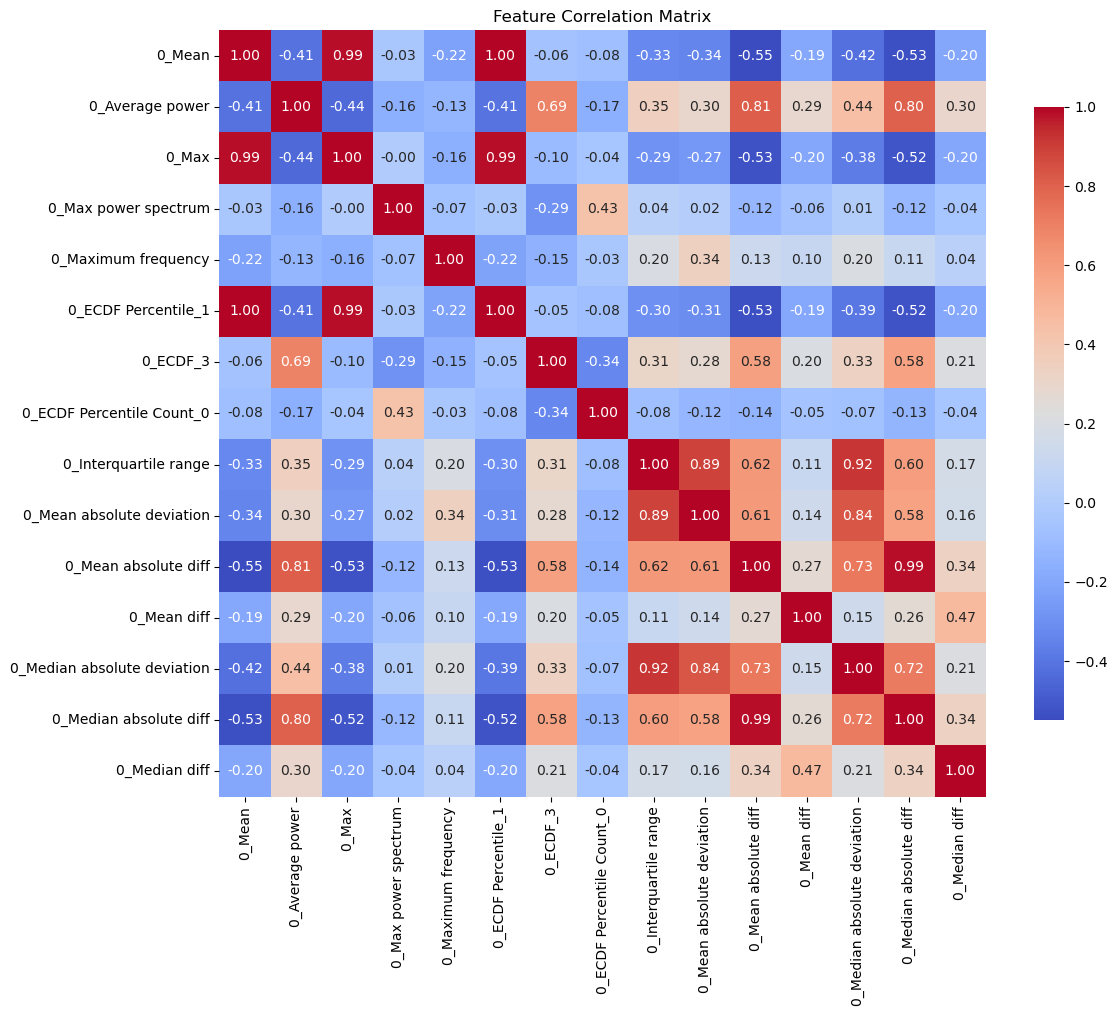

In [7]:
# Compute correlation matrix
corr_matrix = final_feature_df[['0_Mean', '0_Average power', '0_Max',
'0_Max power spectrum',
'0_Maximum frequency',
'0_ECDF Percentile_1',
'0_ECDF_3',
'0_ECDF Percentile Count_0', 
'0_Interquartile range',
'0_Mean absolute deviation',
'0_Mean absolute diff',
'0_Mean diff',
'0_Median absolute deviation',
'0_Median absolute diff',
'0_Median diff']].corr(method='pearson')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


#### Visualizating Spread Across Features

/home/rushang_phira/miniconda3/envs/ml4nanopores-env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning:

divide by zero encountered in divide



Top decisive features: Index(['value__fft_coefficient__attr_"angle"__coeff_0', 'value__count_below__t_0'], dtype='object')


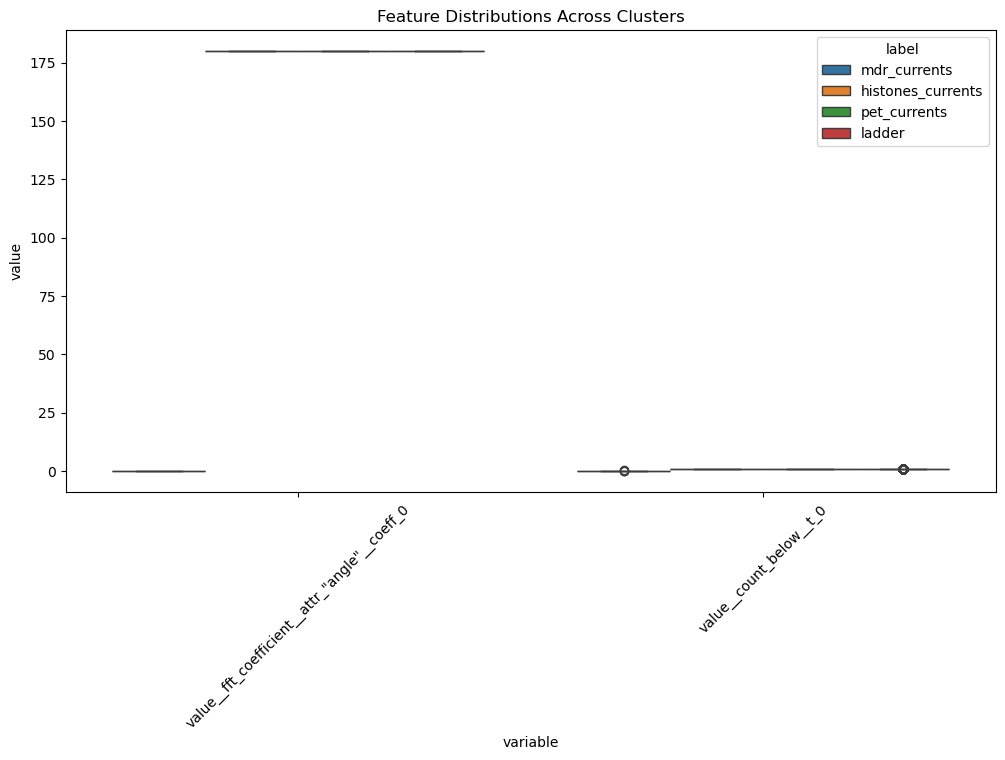

In [ ]:
# X = final_feature_df.drop(columns=['label','0_Mean absolute deviation', '0_Centroid', '0_Mean absolute diff', '0_Median absolute diff', '0_Median frequency', "0_Root mean square", "0_Average power", "0_Histogram mode", "0_Mean", "0_Median", "0_Max", "0_Min"])  # Features
# y = final_feature_df['label']  # Cluster labels

# Compute ANOVA F-statistics
f_values, p_values = f_classif(X, y)

# Select top N features based on F-statistic
top_n = 2
top_features = final_feature_df.columns[np.argsort(-f_values)[:top_n]]
print("Top decisive features:", top_features)
plt.figure(figsize=(12, 6))
df_melted = final_feature_df.drop(columns=['0_Median frequency', "0_Root mean square", "0_Average power", "0_Histogram mode", "0_Mean", "0_Median"]).melt(id_vars=['label'], value_vars=top_features)
sns.boxplot(x="variable", y="value", hue="label", data=df_melted)
plt.xticks(rotation=45)
plt.title("Feature Distributions Across Clusters")
plt.show()

In [ ]:
'''omissions based on knowledge from documentatio to drop mean-correlated features'''

final_feature_df = final_feature_df.drop(columns=[
    '0_ECDF Percentile Count_0', 
    '0_Interquartile range',
    '0_ECDF Percentile Count_1',
    '0_ECDF Percentile_0',
    '0_ECDF Percentile_1',
    '0_ECDF_3',
    '0_ECDF_4',
    '0_ECDF_5',
    '0_ECDF_6',
    '0_ECDF_7',
    '0_ECDF_8',
    '0_ECDF_9',
    '0_Min',
    '0_Max',
    '0_Median frequency', 
    '0_Centroid', 
    '0_Spectral centroid',
    '0_Standard deviation',
    '0_Variance',
    '0_Standard deviation',
    '0_Median frequency', 
    "0_Root mean square", 
    "0_Average power", 
    "0_Histogram mode", 
    "0_Mean", 
    "0_Median"])

features = final_feature_df.drop(columns=[
    'label', 
])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

umap_model = umap.UMAP(n_components=2, random_state=42)
features_pca = umap_model.fit_transform(features_scaled)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(features_scaled)

/home/rushang_phira/miniconda3/envs/ml4nanopores-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/rushang_phira/miniconda3/envs/ml4nanopores-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [17]:
features

,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Entropy,0_Fundamental frequency,0_Human range energy,0_Kurtosis,0_LPCC_0,0_LPCC_1,0_LPCC_10,...,0_Wavelet variance_12.5Hz,0_Wavelet variance_2.78Hz,0_Wavelet variance_25.0Hz,0_Wavelet variance_3.12Hz,0_Wavelet variance_3.57Hz,0_Wavelet variance_4.17Hz,0_Wavelet variance_5.0Hz,0_Wavelet variance_6.25Hz,0_Wavelet variance_8.33Hz,0_Zero crossing rate
0,9.439498e+05,62.241608,4.0,0.991428,2.325581,0.999817,-0.744440,0.194103,1.185784,0.701401,...,1030.314453,3670.290601,294.350596,4148.397276,4727.887610,4750.505774,4214.034683,3268.029995,2104.885511,0.0
1,1.160404e+06,76.922333,5.0,0.986824,1.886792,0.999733,-1.204507,0.234320,1.222723,0.736417,...,918.891315,5056.302860,257.773582,5292.604424,5183.910877,4663.585396,3859.765802,2872.874053,1841.160125,0.0
2,1.069584e+06,71.684296,4.0,0.985825,2.000000,0.999715,0.176468,0.225094,1.225723,0.736563,...,903.905658,4385.759330,242.956249,4813.153879,4958.630514,4695.361894,4088.329642,3137.407513,1957.635185,0.0
3,9.159009e+05,60.552765,5.0,1.000000,2.380952,0.999901,-0.511860,0.188679,1.175986,0.700860,...,1083.300847,3416.670043,310.745451,3477.746735,3916.688412,3971.940814,3558.597254,2840.185705,1991.561871,0.0
4,1.043939e+06,70.027802,3.0,1.000000,4.081633,0.999811,-0.843158,0.212091,1.198506,0.723646,...,1012.027374,4644.676725,283.626028,5160.046842,5250.506137,4749.215900,3850.921641,2786.636290,1845.690025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145607,8.794859e+05,209.251343,5.0,0.972923,0.198020,0.001226,4.672342,0.611236,1.819624,1.255406,...,20.361162,240.509926,2.106468,220.232938,202.748367,184.452960,158.734269,117.818044,64.940522,0.0
145608,2.101916e+06,368.530762,5.0,0.973540,0.306748,0.001417,8.364439,0.724922,1.982979,1.486038,...,19.149989,260.805634,1.665735,212.496860,174.361716,141.425393,112.657583,86.747095,55.544793,0.0
145609,3.891309e+06,772.649506,11.0,0.947080,0.128123,0.003880,13.167258,0.785542,2.219716,1.615110,...,15.480281,205.505580,1.061526,192.444714,174.197942,150.543029,123.105779,90.547699,51.175939,0.0
145610,3.291199e+06,658.747864,9.0,0.954374,0.074349,0.003601,9.784963,0.859400,2.651636,1.884542,...,18.338680,197.390743,1.146307,185.959413,169.799248,147.116266,120.671973,92.008970,56.352748,0.0


In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

def plot_clusters(pca_features, labels, title, label_mapping=None):
    """
    Simple and clean PCA cluster plot with optional label mapping.

    Parameters
    ----------
    pca_features : array-like, shape (n_samples, 2)
        2D PCA or other feature embeddings.
    labels : array-like, shape (n_samples,)
        Cluster labels (numeric or categorical).
    title : str
        Title for the plot.
    label_mapping : dict, optional
        Map numeric labels to descriptive names (e.g. {0: 'Protein A', 1: 'Protein B'}).
    """
    # Prepare data
    df = pd.DataFrame(pca_features, columns=['PCA 1', 'PCA 2'])
    df['Cluster'] = labels

    if label_mapping:
        df['Label'] = df['Cluster'].map(label_mapping).fillna(df['Cluster'].astype(str))
    else:
        df['Label'] = df['Cluster']

    unique_labels = df['Label'].unique()
    colors = cm.tab10(np.linspace(0, 1, len(unique_labels)))

    # === Plot ===
    plt.figure(figsize=(8, 6))
    for color, label in zip(colors, unique_labels):
        subset = df[df['Label'] == label]
        plt.scatter(
            subset['PCA 1'], subset['PCA 2'],
            color=color, s=20, alpha=0.75,
            edgecolors='white', linewidths=0.6,
            label=str(label)
        )

    plt.title(title, fontsize=14, weight='bold')
    plt.xlabel('UMAP Component 1', fontsize=12)
    plt.ylabel('UMAP Component 2', fontsize=12)
    plt.legend(title='Cluster', fontsize=10, title_fontsize=11, frameon=False)
    plt.tight_layout()
    plt.show()


In [99]:
def plot_clusters_interactive(pca_features, labels, title):
    df = pd.DataFrame(pca_features, columns=['PCA Component 1', 'PCA Component 2'])
    df['Cluster'] = labels

    # Create interactive scatter plot
    fig = px.scatter(
        df, 
        x='PCA Component 1', 
        y='PCA Component 2', 
        color=df['Cluster'],  # Ensure categorical colors
        title=title, 
        opacity=0.7,  # Transparency for better visibility
        size_max=2
    )
    fig.show()

In [17]:
ari_score = adjusted_rand_score(final_feature_df["label"], kmeans_labels)
print(f"ARI: {ari_score}")

ARI: 0.9343174313291382


In [25]:
import numpy as np
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# true_labels = ground-truth labels
# cluster_labels_base = baseline cluster labels
# cluster_labels_new = your improved cluster labels

# Hungarian alignment for both clusterings
from scipy.optimize import linear_sum_assignment

def hungarian_remap(y_true, y_pred):
    labels_true = np.unique(y_true)
    labels_pred = np.unique(y_pred)
    cost_matrix = np.zeros((len(labels_true), len(labels_pred)), dtype=int)
    for i, true_label in enumerate(labels_true):
        for j, pred_label in enumerate(labels_pred):
            cost_matrix[i, j] = np.sum((y_true == true_label) & (y_pred != pred_label))
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = {labels_pred[col]: labels_true[row] for row, col in zip(row_ind, col_ind)}
    return np.vectorize(mapping.get)(y_pred)

base_mapped = hungarian_remap(final_feature_df["label"], kmeans_labels)
new_mapped = hungarian_remap(final_feature_df["label"], labels)

# Step 2: Compute ARI and confusion difference
ari_base = adjusted_rand_score(final_feature_df["label"], base_mapped)
ari_new = adjusted_rand_score(final_feature_df["label"], new_mapped)

# Step 3: Count how many samples changed cluster assignments correctly
correct_base = np.sum(base_mapped == final_feature_df["label"])
correct_new = np.sum(new_mapped == final_feature_df["label"])

delta_correct = correct_new - correct_base
n_total = len(final_feature_df["label"])

print(f"Baseline ARI: {ari_base:.6f}")
print(f"New ARI: {ari_new:.6f}")
print(f"Improved correctly classified samples: {delta_correct} / {n_total} ({delta_correct / n_total * 100:.3f}%)")


Baseline ARI: 0.934317
New ARI: 0.950094
Improved correctly classified samples: 516 / 145612 (0.354%)


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute precision, recall, and F1-score for each label (class)
precision_base = precision_score(final_feature_df["label"], base_mapped, average=None)
recall_base = recall_score(final_feature_df["label"], base_mapped, average=None)
f1_base = f1_score(final_feature_df["label"], base_mapped, average=None)

precision_new = precision_score(final_feature_df["label"], new_mapped, average=None)
recall_new = recall_score(final_feature_df["label"], new_mapped, average=None)
f1_new = f1_score(final_feature_df["label"], new_mapped, average=None)

# Print out the metrics
print(f"Precision (Base): {precision_base}")
print(f"Recall (Base): {recall_base}")
print(f"F1-Score (Base): {f1_base}")
print(f"Precision (New): {precision_new}")
print(f"Recall (New): {recall_new}")
print(f"F1-Score (New): {f1_new}")


Precision (Base): [0.9632 0.9986 0.9938 1.    ]
Recall (Base): [0.999  0.9521 0.9849 1.    ]
F1-Score (Base): [0.9808 0.9748 0.9893 1.    ]
Precision (New): [0.9679 0.9992 0.9996 1.    ]
Recall (New): [0.9997 0.973  0.9337 1.    ]
F1-Score (New): [0.9835 0.9859 0.9655 1.    ]


In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from scipy.optimize import linear_sum_assignment

# Assuming you have the necessary columns and functions already defined

# Hungarian alignment for both clusterings
def hungarian_remap(y_true, y_pred):
    labels_true = np.unique(y_true)
    labels_pred = np.unique(y_pred)
    cost_matrix = np.zeros((len(labels_true), len(labels_pred)), dtype=int)
    for i, true_label in enumerate(labels_true):
        for j, pred_label in enumerate(labels_pred):
            cost_matrix[i, j] = np.sum((y_true == true_label) & (y_pred != pred_label))
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = {labels_pred[col]: labels_true[row] for row, col in zip(row_ind, col_ind)}
    return np.vectorize(mapping.get)(y_pred)

# Compute Hungarian-aligned cluster labels for both models
base_mapped = hungarian_remap(final_feature_df["label"], kmeans_labels)
new_mapped  = hungarian_remap(final_feature_df["label"], labels)

# Compute confusion matrices (aligned to the same true label order)
labels_order = np.unique(final_feature_df["label"])
cm_base = confusion_matrix(final_feature_df["label"], base_mapped, labels=labels_order)
cm_new  = confusion_matrix(final_feature_df["label"], new_mapped, labels=labels_order)

# Get Precision, Recall, and F1-Score for each class
precision_base, recall_base, f1_base, _ = precision_recall_fscore_support(final_feature_df["label"], base_mapped, labels=labels_order, average=None)
precision_new, recall_new, f1_new, _ = precision_recall_fscore_support(final_feature_df["label"], new_mapped, labels=labels_order, average=None)

# Print out metrics with class names
print(f"{'Class Name':<15}{'Precision (Base)':<20}{'Recall (Base)':<20}{'F1-Score (Base)':<20}{'Precision (New)':<20}{'Recall (New)':<20}{'F1-Score (New)'}")
print("-" * 120)

for idx, class_name in enumerate(labels_order):
    print(f"{class_name:<15}{precision_base[idx]:<20.4f}{recall_base[idx]:<20.4f}{f1_base[idx]:<20.4f}{precision_new[idx]:<20.4f}{recall_new[idx]:<20.4f}{f1_new[idx]:<20.4f}")


Class Name     Precision (Base)    Recall (Base)       F1-Score (Base)     Precision (New)     Recall (New)        F1-Score (New)
------------------------------------------------------------------------------------------------------------------------
histones_currents0.9632              0.9990              0.9808              0.9679              0.9997              0.9835              
ladder         0.9986              0.9521              0.9748              0.9992              0.9730              0.9859              
mdr_currents   0.9938              0.9849              0.9893              0.9996              0.9337              0.9655              
pet_currents   1.0000              1.0000              1.0000              1.0000              1.0000              1.0000              


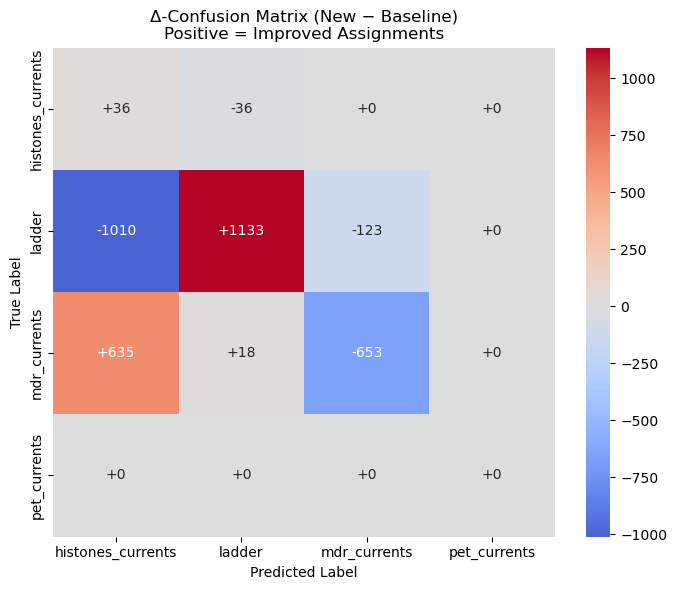

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute Hungarian-aligned cluster labels for both models
base_mapped = hungarian_remap(final_feature_df["label"], kmeans_labels)
new_mapped  = hungarian_remap(final_feature_df["label"], labels)

# Compute confusion matrices (aligned to the same true label order)
labels_order = np.unique(final_feature_df["label"])
cm_base = confusion_matrix(final_feature_df["label"], base_mapped, labels=labels_order)
cm_new  = confusion_matrix(final_feature_df["label"], new_mapped, labels=labels_order)

# Compute the difference (Δ)
cm_diff = cm_new - cm_base

# Normalize if you want relative differences
cm_diff_norm = cm_diff / cm_base.clip(min=1)

# Plot Δ-confusion heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm_diff, annot=True, fmt="+d", cmap="coolwarm", center=0,
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Δ-Confusion Matrix (New − Baseline)\nPositive = Improved Assignments")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [23]:
print(normalized_mutual_info_score(final_feature_df["label"], labels))
print(normalized_mutual_info_score(final_feature_df["label"], kmeans_labels))


0.929529283771841
0.9200425728215924


#### Trying Sparse Feature Selection. Copied function over from sparse_final.py, with a search for sparsity constraint

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, adjusted_rand_score, silhouette_score
from scipy.optimize import bisect

def soft_threshold(x, delta):
    """Soft-thresholding operator"""
    return np.sign(x) * np.maximum(np.abs(x) - delta, 0)

def compute_cer(true_labels, cluster_labels):
    """Compute classification error rate"""
    cm = confusion_matrix(true_labels, cluster_labels)
    return 1 - np.trace(cm) / np.sum(cm)

def sparse_kmeans(X, K, s, true_labels=None, max_iter=1000, tol=1e-6, patience=50, min_iter=10, random_state=42):

    """
    Sparse K-means clustering following Witten & Tibshirani (2010)
    
    Parameters:
    - X: numpy array of shape (n, p)
    - K: int, number of clusters
    - s: float, L1 bound on weights (1 <= s <= sqrt(p))
    - true_labels: optional true labels for evaluation
    - max_iter: int, maximum iterations
    - tol: float, convergence tolerance
    - random_state: random seed
    
    Returns:
    - cluster_labels: array of cluster assignments
    - weights: array of feature weights
    - metrics: dictionary of performance metrics
    """
    n, p = X.shape
    
    # validate parameters
    if s < 1 or s > np.sqrt(p):
        raise ValueError(f"s must be between 1 and sqrt(p)={np.sqrt(p):.2f}")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # weight initialization
    weights = np.ones(p) / np.sqrt(p)
    objective_history = []
    weight_history = [weights.copy()]

    # Early stopping variables
    best_weights = weights.copy()
    best_objective = -np.inf
    patience_counter = 0
    converged = False
    print(f"{n} samples, {p} features, s={s}")
    
    for iteration in range(max_iter):
        # Weighted K-means clustering
        weighted_X = X_scaled * np.sqrt(weights)
        kmeans = KMeans(n_clusters=K, random_state=random_state, n_init=10)
        cluster_labels = kmeans.fit_predict(weighted_X)
        
        # Compute BCSS
        BCSS = np.zeros(p)
        for j in range(p):
            # Total sum of squares for feature j
            overall_mean = np.mean(X_scaled[:, j])
            total_ss = np.sum((X_scaled[:, j] - overall_mean) ** 2)
            
            # Within cluster sum of squares for feature j
            within_ss = 0
            for k in range(K):
                cluster_indices = (cluster_labels == k)
                n_k = np.sum(cluster_indices)
                if n_k > 0:  # Avoid empty clusters
                    cluster_mean = np.mean(X_scaled[cluster_indices, j])
                    within_ss += np.sum((X_scaled[cluster_indices, j] - cluster_mean) ** 2)
            
            # BCSS = Total SS - Within SS
            BCSS[j] = (total_ss - within_ss)
        
        # Update weights with L1 constraint enforcement
        a = BCSS
        
        # Scale BCSS to unit norm for numerical stability
        a = a / (np.linalg.norm(a, 2) + 1e-10)
        
        # Binary search for delta to satisfy ||w||₁ = s
        def l1_norm(delta):
            w_temp = soft_threshold(a, delta)
            norm_w = np.linalg.norm(w_temp, 2)
            if norm_w > 0:
                w_temp = w_temp / norm_w
            return np.sum(np.abs(w_temp)) - s
        
        # Check if constraint is already satisfied
        current_l1 = np.sum(np.abs(a / (np.linalg.norm(a, 2) + 1e-10)))
        
        if current_l1 <= s:
            delta = 0
            w_new = a
        else:
            # Binary search for optimal delta
            delta_low, delta_high = 0, np.max(np.abs(a))
            delta = bisect(l1_norm, delta_low, delta_high, xtol=1e-8, maxiter=50)
            w_new = soft_threshold(a, delta)
        
        # Normalize final weights
        norm_w = np.linalg.norm(w_new, 2)
        if norm_w > 0:
            w_new = w_new / norm_w
        else:
            w_new = np.ones(p) / np.sqrt(p)
        
        # Calculate objective
        current_objective = np.sum(w_new * BCSS)
        objective_history.append(current_objective)
        weight_history.append(w_new.copy())

        # Check for improvement
        if current_objective > best_objective:
            best_objective = current_objective
            best_weights = w_new.copy()
            patience_counter = 0
        else:
            patience_counter += 1

        # Check convergence
        weight_change = np.linalg.norm(w_new - weights, 2)
        n_nonzero = np.sum(w_new > 1e-6)
        
        print(f"Iteration {iteration + 1}:")
        print(f"  - BCSS range: [{BCSS.min():.6f}, {BCSS.max():.6f}]")
        print(f"  - Weight change: {weight_change:.6f}")
        print(f"  - Objective: {current_objective:.6f}")
        print(f"  - Non-zero features: {n_nonzero}/{p} ({n_nonzero/p*100:.1f}%)")
        
        # Early stopping conditions
        if weight_change < tol and iteration >= min_iter:
            print(f"converged after {iteration + 1} iterations (weight change < {tol})")
            converged = True
            break
        elif patience_counter >= patience and iteration >= min_iter:
            print(f"early stopping after {iteration + 1} iterations (no improvement for {patience} iterations)")
            converged = True
            break
            
        weights = w_new
    if not converged:
            print(f"reached maximum iterations ({max_iter})")
    
    # Use best weights found
    final_weights = best_weights
    final_n_nonzero = np.sum(final_weights > 1e-6)
    
    print(f"Final: {final_n_nonzero} non-zero features, Best objective: {best_objective:.6f}")
    
    return cluster_labels, final_weights, objective_history
    
    # Compute final metrics
    # metrics = {}
    # if true_labels is not None:
    #     metrics['CER'] = compute_cer(true_labels, cluster_labels)
    #     metrics['ARI'] = adjusted_rand_score(true_labels, cluster_labels)
    
    # metrics['Silhouette'] = silhouette_score(X_scaled, cluster_labels)
    # metrics['Nonzero_Features'] = np.sum(weights > 1e-6)
    # metrics['Sparsity_Ratio'] = np.sum(weights > 1e-6) / p
    # metrics['Iterations'] = len(objective_history)
    # metrics['Final_Objective'] = current_objective
    
    # print(f"\nFINAL RESULTS")
    # print(f"Selected {metrics['Nonzero_Features']} out of {p} features")
    # if true_labels is not None:
    #     print(f"ARI: {metrics['ARI']:.3f}, CER: {metrics['CER']:.3f}")
    # print(f"Silhouette: {metrics['Silhouette']:.3f}")

    # Compute final metrics
    # metrics = {}
    # if true_labels is not None:
    #     metrics['CER'] = compute_cer(true_labels, cluster_labels)
    #     metrics['ARI'] = adjusted_rand_score(true_labels, cluster_labels)
    
    # metrics['Silhouette'] = silhouette_score(X_scaled, cluster_labels)
    # metrics['Nonzero_Features'] = np.sum(weights > 1e-6)
    # metrics['Sparsity_Ratio'] = np.sum(weights > 1e-6) / p
    # metrics['Iterations'] = len(objective_history)
    # metrics['Final_Objective'] = current_objective
    
    # print(f"\nFINAL RESULTS:")
    # print(f"Selected {metrics['Nonzero_Features']} out of {p} features")
    # if true_labels is not None:
    #     print(f"ARI: {metrics['ARI']:.3f}, CER: {metrics['CER']:.3f}")
    # print(f"Silhouette: {metrics['Silhouette']:.3f}")
    

In [ ]:
def find_optimal_sparsity(X, K, true_labels=None, sparsity_range=None, 
                         max_iter=50, random_state=42, metric='ari'):
    """
    Find optimal sparsity parameter s for sparse K-means by maximimizing ARI
    
    Parameters:
    - X: feature matrix
    - K: number of clusters
    - true_labels: true labels for evaluation (optional)
    - sparsity_range: range of s values to try
    - max_iter: maximum iterations per run
    - random_state: random seed
    - metric: evaluation metric ('silhouette', 'ari', or 'objective')
    
    Returns:
    - best_s: optimal sparsity parameter
    - best_score: best score achieved
    - results: dictionary with all results
    """
    n, p = X.shape
    
    # Default sparsity range if not provided
    if sparsity_range is None:
        sparsity_range = np.linspace(1.0, min(10.0, np.sqrt(p)), 8)
    
    results = {}
    best_score = -np.inf
    best_s = None
    best_labels = None
    best_weights = None
    
    print(f"Searching for optimal sparsity in range: {sparsity_range}")
    print(f"Using metric: {metric}")
    
    for s in sparsity_range:
        print(f"\n--- Testing s={s:.2f} ---")
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                
                labels, weights, objectives = sparse_kmeans(
                    X=X, K=K, s=s, true_labels=true_labels,
                    max_iter=max_iter, random_state=random_state,
                    patience=5, min_iter=5
                )
            
            # Calculate evaluation metric
            if metric == 'silhouette':
                from sklearn.metrics import silhouette_score
                X_scaled = StandardScaler().fit_transform(X)
                score = silhouette_score(X_scaled, labels)
            elif metric == 'ari' and true_labels is not None:
                score = adjusted_rand_score(true_labels, labels)
            elif metric == 'objective':
                score = objectives[-1] if objectives else -np.inf
            else:
                # Default to silhouette
                X_scaled = StandardScaler().fit_transform(X)
                score = silhouette_score(X_scaled, labels)
            
            n_nonzero = np.sum(weights > 1e-6)
            results[s] = {
                'score': score,
                'n_nonzero': n_nonzero,
                'weights': weights,
                'labels': labels,
                'objectives': objectives
            }
            
            print(f"s={s:.2f}: {metric}={score:.4f}, non-zero features={n_nonzero}")
            
            if score > best_score:
                best_score = score
                best_s = s
                best_labels = labels
                best_weights = weights
                
        except Exception as e:
            print(f"Failed for s={s:.2f}: {e}")
            results[s] = None
    
    print(f"\nOPTIMAL RESULT: s={best_s:.2f}, {metric}={best_score:.4f}")
    print(f"Selected {np.sum(best_weights > 1e-6)} non-zero features")
    
    return best_s, best_score, best_labels, best_weights, results

In [42]:
features

,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Entropy,0_Fundamental frequency,0_Human range energy,0_Kurtosis,0_LPCC_0,0_LPCC_1,0_LPCC_10,...,0_Wavelet variance_12.5Hz,0_Wavelet variance_2.78Hz,0_Wavelet variance_25.0Hz,0_Wavelet variance_3.12Hz,0_Wavelet variance_3.57Hz,0_Wavelet variance_4.17Hz,0_Wavelet variance_5.0Hz,0_Wavelet variance_6.25Hz,0_Wavelet variance_8.33Hz,0_Zero crossing rate
0,9.439498e+05,62.241608,4.0,0.991428,2.325581,0.999817,-0.744440,0.194103,1.185784,0.701401,...,1030.314453,3670.290601,294.350596,4148.397276,4727.887610,4750.505774,4214.034683,3268.029995,2104.885511,0.0
1,1.160404e+06,76.922333,5.0,0.986824,1.886792,0.999733,-1.204507,0.234320,1.222723,0.736417,...,918.891315,5056.302860,257.773582,5292.604424,5183.910877,4663.585396,3859.765802,2872.874053,1841.160125,0.0
2,1.069584e+06,71.684296,4.0,0.985825,2.000000,0.999715,0.176468,0.225094,1.225723,0.736563,...,903.905658,4385.759330,242.956249,4813.153879,4958.630514,4695.361894,4088.329642,3137.407513,1957.635185,0.0
3,9.159009e+05,60.552765,5.0,1.000000,2.380952,0.999901,-0.511860,0.188679,1.175986,0.700860,...,1083.300847,3416.670043,310.745451,3477.746735,3916.688412,3971.940814,3558.597254,2840.185705,1991.561871,0.0
4,1.043939e+06,70.027802,3.0,1.000000,4.081633,0.999811,-0.843158,0.212091,1.198506,0.723646,...,1012.027374,4644.676725,283.626028,5160.046842,5250.506137,4749.215900,3850.921641,2786.636290,1845.690025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145607,8.794859e+05,209.251343,5.0,0.972923,0.198020,0.001226,4.672342,0.611236,1.819624,1.255406,...,20.361162,240.509926,2.106468,220.232938,202.748367,184.452960,158.734269,117.818044,64.940522,0.0
145608,2.101916e+06,368.530762,5.0,0.973540,0.306748,0.001417,8.364439,0.724922,1.982979,1.486038,...,19.149989,260.805634,1.665735,212.496860,174.361716,141.425393,112.657583,86.747095,55.544793,0.0
145609,3.891309e+06,772.649506,11.0,0.947080,0.128123,0.003880,13.167258,0.785542,2.219716,1.615110,...,15.480281,205.505580,1.061526,192.444714,174.197942,150.543029,123.105779,90.547699,51.175939,0.0
145610,3.291199e+06,658.747864,9.0,0.954374,0.074349,0.003601,9.784963,0.859400,2.651636,1.884542,...,18.338680,197.390743,1.146307,185.959413,169.799248,147.116266,120.671973,92.008970,56.352748,0.0


In [20]:
features_scaled.shape

(145612, 106)

In [22]:
labels, weights, objectives = sparse_kmeans(
    X=features_scaled, K=4, s=8.6, true_labels=final_feature_df[["label"]],
    max_iter=1000, random_state=42,
    patience=5, min_iter=5
)

145612 samples, 106 features, s=8.6


Iteration 1:
  - BCSS range: [20.036074, 141587.033664]
  - Weight change: 0.506354
  - Objective: 0.994888
  - Non-zero features: 97/106 (91.5%)
Iteration 2:
  - BCSS range: [19.988921, 141680.175366]
  - Weight change: 0.011810
  - Objective: 0.995614
  - Non-zero features: 97/106 (91.5%)
Iteration 3:
  - BCSS range: [19.992328, 141681.574409]
  - Weight change: 0.000381
  - Objective: 0.995624
  - Non-zero features: 97/106 (91.5%)
Iteration 4:
  - BCSS range: [19.991891, 141681.574177]
  - Weight change: 0.000038
  - Objective: 0.995625
  - Non-zero features: 97/106 (91.5%)
Iteration 5:
  - BCSS range: [19.990225, 141681.573657]
  - Weight change: 0.000030
  - Objective: 0.995625
  - Non-zero features: 97/106 (91.5%)
Iteration 6:
  - BCSS range: [19.988167, 141681.689945]
  - Weight change: 0.000022
  - Objective: 0.995626
  - Non-zero features: 97/106 (91.5%)
Iteration 7:
  - BCSS range: [19.988169, 141681.690039]
  - Weight change: 0.000012
  - Objective: 0.995626
  - Non-zero fea

Adjusted Rand Index (ARI):  0.9500940927651396


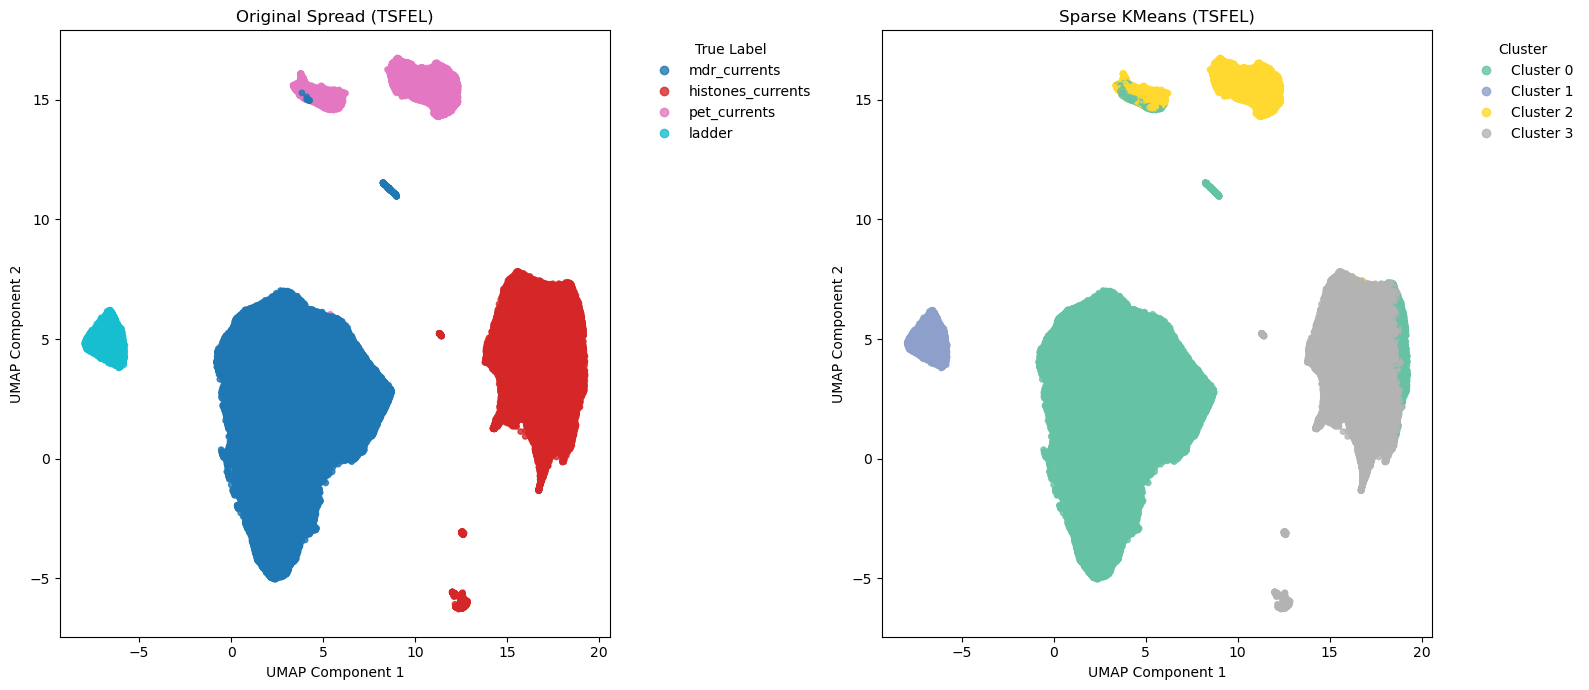

In [15]:
print("Adjusted Rand Index (ARI): ", adjusted_rand_score(labels, final_feature_df["label"]))

import matplotlib.pyplot as plt

# Assuming you have:
# features_pca: (n_samples, 2) PCA-reduced features
# final_feature_df["label"]: true labels (categorical)
# kmeans_labels: cluster labels (integers)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Original Spread ---
scatter1 = axes[0].scatter(
    features_pca[:, 0], features_pca[:, 1],
    c=final_feature_df["label"].astype('category').cat.codes,
    cmap='tab10', s=15, alpha=0.8
)
axes[0].set_title("Original Spread (TSFEL)")
axes[0].set_xlabel("UMAP Component 1")
axes[0].set_ylabel("UMAP Component 2")

# --- Right: KMeans Clusters ---
scatter2 = axes[1].scatter(
    features_pca[:, 0], features_pca[:, 1],
    c=labels, cmap='Set2', s=15, alpha=0.8
)
axes[1].set_title("Sparse KMeans (TSFEL)")
axes[1].set_xlabel("UMAP Component 1")
axes[1].set_ylabel("UMAP Component 2")

# --- Legends ---
handles1, labels1 = scatter1.legend_elements()
axes[0].legend(handles1, final_feature_df["label"].unique(), title="True Label",
               bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

handles2, labels2 = scatter2.legend_elements()
axes[1].legend(handles2, [f"Cluster {i}" for i in sorted(set(kmeans_labels))],
               title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


In [89]:
np.save('weights.npy', weights)

In [ ]:
print("Adjusted Rand Index (ARI): ", adjusted_rand_score(labels, final_feature_df["label"]))

NameError: name 'cluster_labels' is not defined

In [29]:
from sklearn.metrics import homogeneity_completeness_v_measure

hom, comp, v = homogeneity_completeness_v_measure(final_feature_df["label"], labels)
print(f"Homogeneity: {hom}, Completeness: {comp}, V-Measure: {v}")
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(features_scaled, labels)
print("Calinski-Harabasz Index:", ch_score)
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(features_scaled, labels)
print("Davies-Bouldin Index:", db_score)

Homogeneity: 0.9245715575810275, Completeness: 0.9345404651155548, V-Measure: 0.9295292837718411
Calinski-Harabasz Index: 73873.9470162243
Davies-Bouldin Index: 1.2182867544156974


In [30]:
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score, confusion_matrix

true_labels = np.array(final_feature_df["label"])      # your true labels
cluster_labels = np.array(labels) # your cluster assignments

labels_true = np.unique(true_labels)
labels_cluster = np.unique(cluster_labels)

# Build cost matrix: number of points in cluster j NOT in true label i
cost_matrix = np.zeros((len(labels_true), len(labels_cluster)), dtype=int)
for i, true_label in enumerate(labels_true):
    for j, cluster_label in enumerate(labels_cluster):
        cost_matrix[i, j] = np.sum((true_labels == true_label) & (cluster_labels != cluster_label))

# Hungarian algorithm (minimize total cost)
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# Build mapping from cluster to true label
mapping = {labels_cluster[col]: labels_true[row] for row, col in zip(row_ind, col_ind)}

# Remap cluster labels
new_cluster_labels = np.vectorize(mapping.get)(cluster_labels)

print("Cluster -> True label mapping:", mapping)
print("Accuracy after mapping:", accuracy_score(true_labels, new_cluster_labels))
print("Confusion matrix after mapping:\n", confusion_matrix(true_labels, new_cluster_labels))


Cluster -> True label mapping: {0: 'histones_currents', 3: 'ladder', 2: 'mdr_currents', 1: 'pet_currents'}
Accuracy after mapping: 0.9842595390489794
Confusion matrix after mapping:
 [[70955    15     0     0]
 [ 1477 52511    31     0]
 [  751    18 13043     0]
 [    0     0     0  6811]]


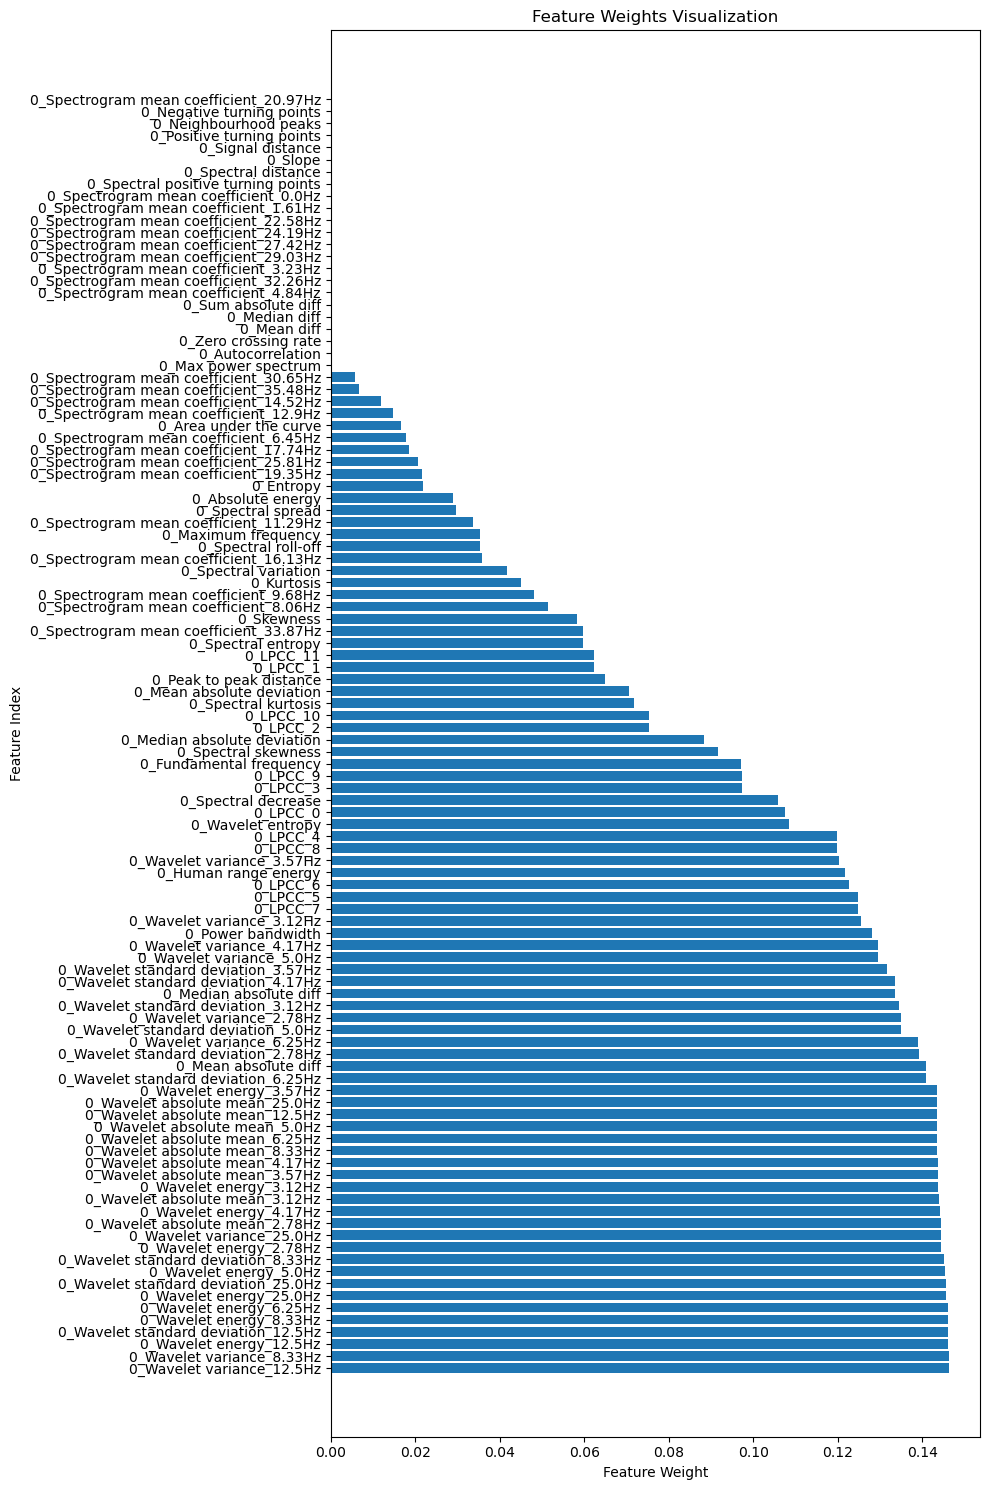

In [26]:
feature_names = features.columns
sorted_indices = np.argsort(weights)[::-1]

# Sort weights and feature names
sorted_weights = weights[sorted_indices]
sorted_feature_names = np.array(feature_names)[sorted_indices] if feature_names is not None else np.arange(len(weights))[sorted_indices]

plt.figure(figsize=(10, 15))
plt.barh(sorted_feature_names, sorted_weights)
plt.xlabel('Feature Weight')
plt.ylabel('Feature Index')
plt.title('Feature Weights Visualization')
plt.tight_layout()
plt.show()

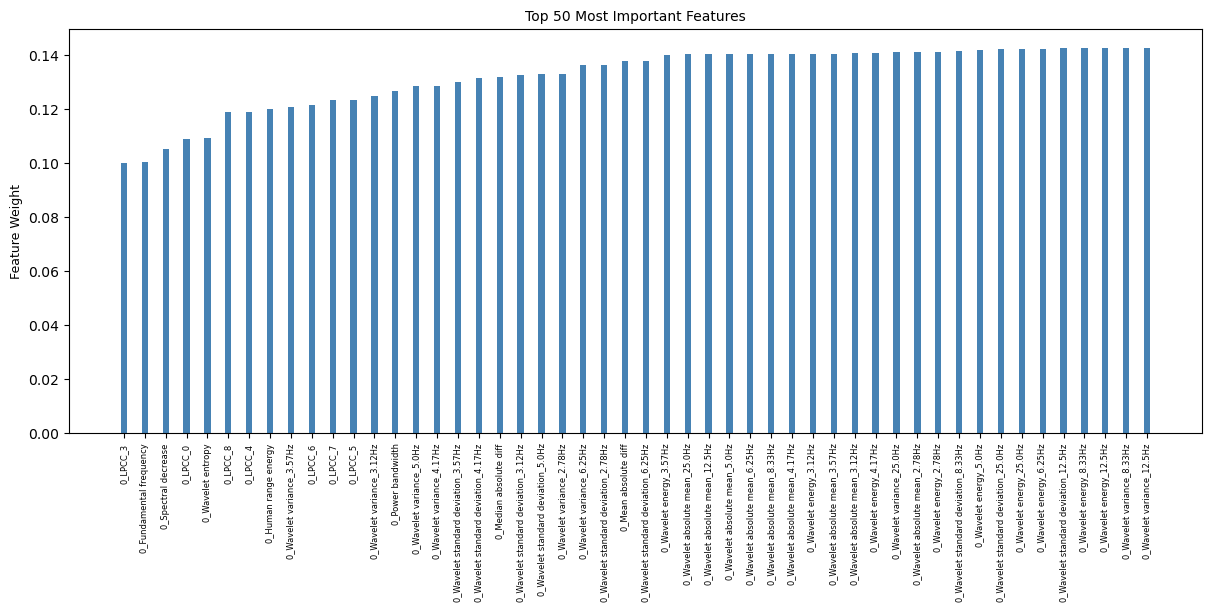

In [32]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = features.columns
sorted_indices = np.argsort(weights)[::-1]

# Sort weights and feature names
sorted_weights = weights[sorted_indices]
sorted_feature_names = np.array(feature_names)[sorted_indices]

# Select top 50 features
top_n = 50
top_weights = sorted_weights[:top_n]
top_features = sorted_feature_names[:top_n]

# --- Compact vertical bar plot ---
plt.figure(figsize=(12, 6))  # wide and short for vertical bars
bars = plt.bar(np.arange(top_n), top_weights[::-1], color="steelblue", width=0.3)  # narrow bars

# Add feature names as x-ticks
plt.xticks(np.arange(top_n), top_features[::-1], rotation=90, fontsize=6)
plt.ylabel("Feature Weight", fontsize=9)
plt.title(f"Top {top_n} Most Important Features", fontsize=10, pad=6)

plt.tight_layout(pad=0.3)
plt.show()



Feature Analysis by Cluster (Original Scale)

--- Cluster 0 (n=73183) ---
   1. 0_Wavelet variance_12.5Hz | Cluster:   18.268 | Others:  433.822 | Diff: -415.554 ( -95.8%) LOWER ***
   2. 0_Wavelet variance_8.33Hz | Cluster:   52.635 | Others:  739.042 | Diff: -686.408 ( -92.9%) LOWER ***
   3. 0_Wavelet energy_12.5Hz | Cluster:    4.194 | Others:   14.071 | Diff:   -9.878 ( -70.2%) LOWER ***
   4. 0_Wavelet energy_8.33Hz | Cluster:    7.179 | Others:   21.884 | Diff:  -14.705 ( -67.2%) LOWER ***
   5. 0_Wavelet standard deviation_12.5Hz | Cluster:    4.183 | Others:   12.377 | Diff:   -8.194 ( -66.2%) LOWER ***
   6. 0_Wavelet energy_6.25Hz | Cluster:    9.841 | Others:   29.155 | Diff:  -19.314 ( -66.2%) LOWER ***
   7. 0_Wavelet energy_25.0Hz | Cluster:    1.608 | Others:    6.343 | Diff:   -4.735 ( -74.7%) LOWER ***
   8. 0_Wavelet standard deviation_25.0Hz | Cluster:    1.605 | Others:    5.988 | Diff:   -4.383 ( -73.2%) LOWER ***
   9. 0_Wavelet energy_5.0Hz | Cluster:   12.049 

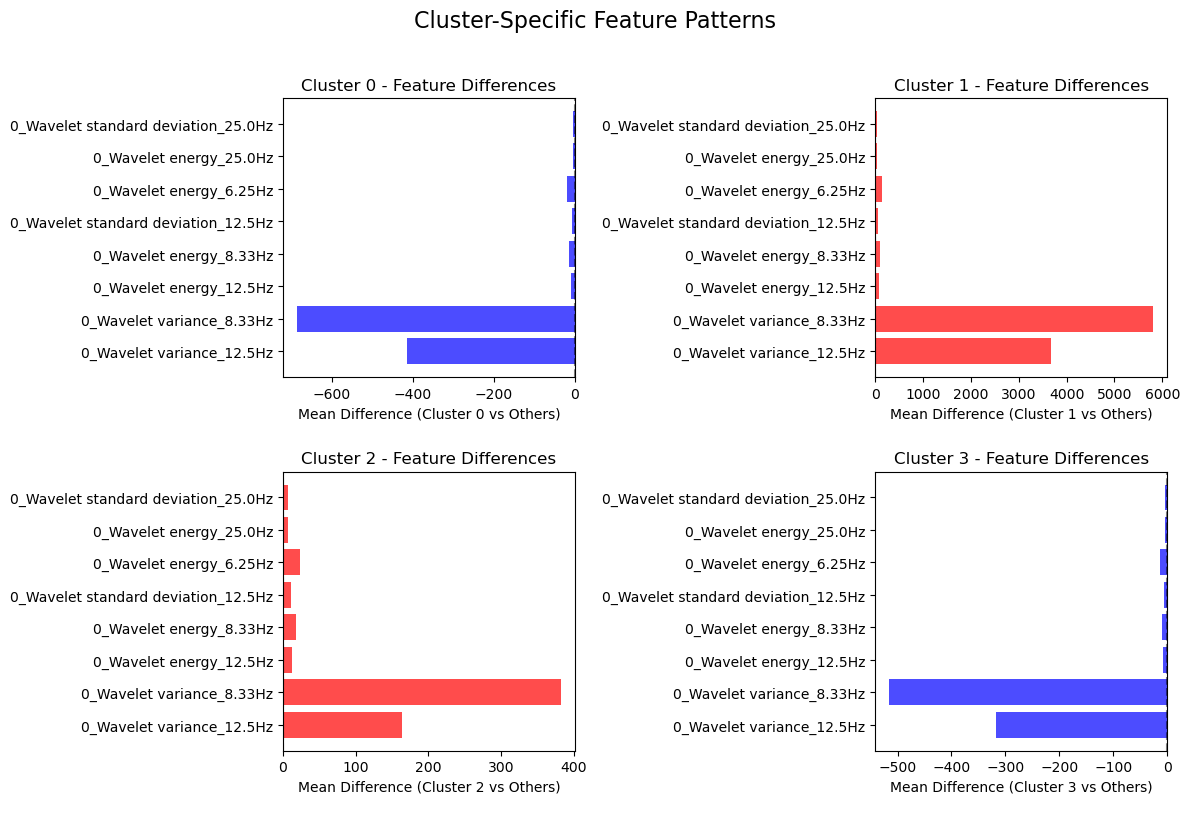

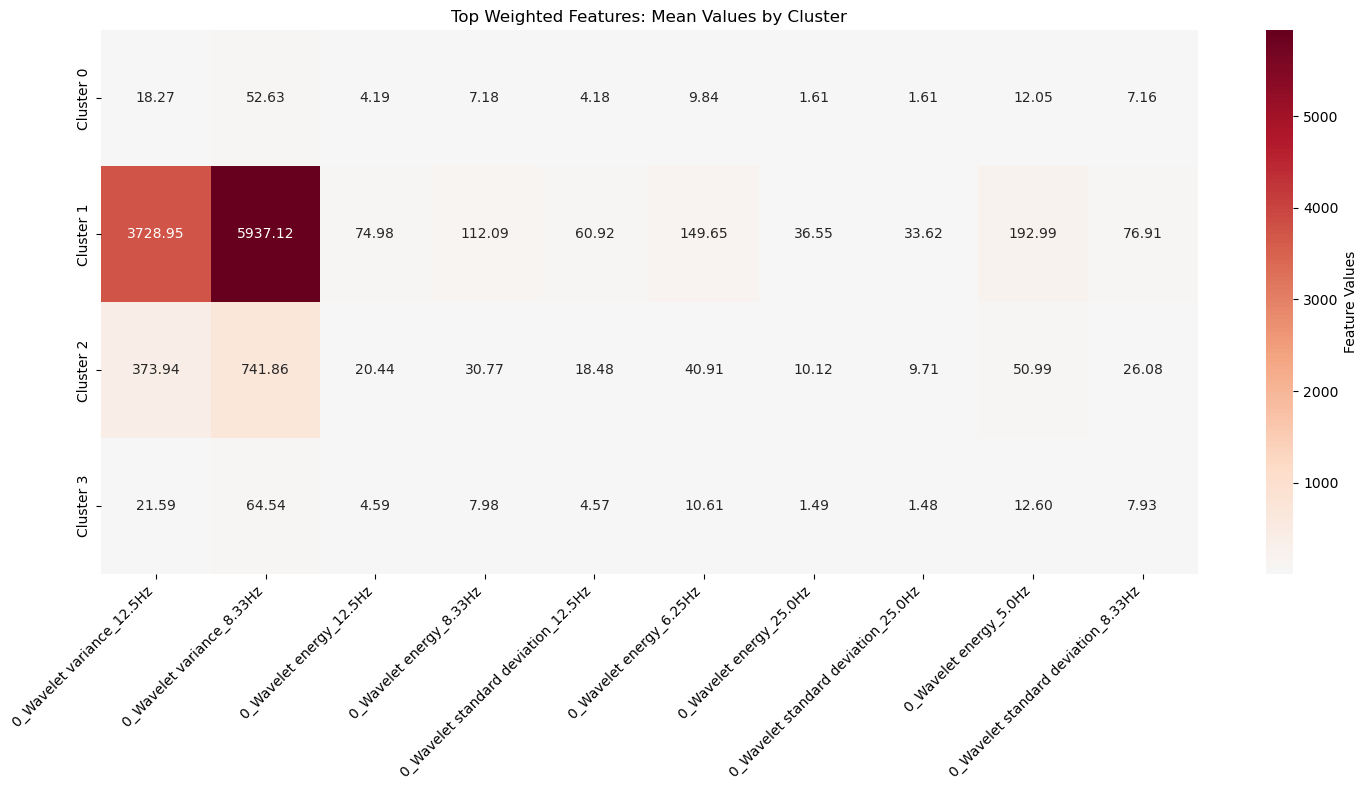

In [ ]:
print("\n" + "="*50)
print("Feature Analysis by Cluster (Original Scale)")
print("="*50)

# Use original unscaled features for interpretation
features_original = features.values

# Analyze top features for each cluster
top_n = 10
top_feature_indices = np.argsort(weights)[-top_n:][::-1]  # Top N weighted features

for cluster_id in np.unique(labels):
    cluster_mask = labels == cluster_id
    other_mask = labels != cluster_id
    
    print(f"\n--- Cluster {cluster_id} (n={np.sum(cluster_mask)}) ---")
    
    for i, feat_idx in enumerate(top_feature_indices):
        if weights[feat_idx] > 0.01:  # Only show meaningful weights
            feat_name = feature_names[feat_idx] if feature_names is not None else f"Feature_{feat_idx}"
            
            # Calculate mean difference on ORIGINAL scale
            cluster_mean = np.mean(features_original[cluster_mask, feat_idx])
            other_mean = np.mean(features_original[other_mask, feat_idx])
            mean_diff = cluster_mean - other_mean
            percent_diff = (mean_diff / other_mean) * 100 if other_mean != 0 else float('inf')
            
            # Statistical test
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(features_original[cluster_mask, feat_idx], 
                                            features_original[other_mask, feat_idx], 
                                            equal_var=False)
            
            direction = "HIGHER" if mean_diff > 0 else "LOWER"
            significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
            
            print(f"  {i+1:2d}. {feat_name:<20} | "
                  f"Cluster: {cluster_mean:8.3f} | Others: {other_mean:8.3f} | "
                  f"Diff: {mean_diff:8.3f} ({percent_diff:6.1f}%) {direction} {significance}")

# Create cluster-specific feature importance plot
plt.figure(figsize=(12, 8))

for i, cluster_id in enumerate(np.unique(labels)):
    plt.subplot(2, 2, i+1)
    
    cluster_mask = labels == cluster_id
    other_mask = labels != cluster_id
    
    # Calculate mean differences for top features
    feature_differences = []
    feature_original_names = []
    for feat_idx in top_feature_indices[:8]:  # Top 8 only
        cluster_mean = np.mean(features_original[cluster_mask, feat_idx])
        other_mean = np.mean(features_original[other_mask, feat_idx])
        feature_differences.append(cluster_mean - other_mean)
        feature_original_names.append(feature_names[feat_idx] if feature_names is not None else f"Feature_{feat_idx}")
    
    colors = ['red' if diff > 0 else 'blue' for diff in feature_differences]
    plt.barh(feature_original_names, feature_differences, color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel(f'Mean Difference (Cluster {cluster_id} vs Others)\n')
    plt.title(f'Cluster {cluster_id} - Feature Differences')
    plt.tight_layout()

plt.suptitle('Cluster-Specific Feature Patterns', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))

# Get feature means for each cluster
cluster_means_original = []
for cluster_id in np.unique(labels):
    cluster_mask = labels == cluster_id
    cluster_feature_means = [np.mean(features_original[cluster_mask, idx]) for idx in top_feature_indices[:15]]
    cluster_means_original.append(cluster_feature_means)

cluster_means_original = np.array(cluster_means_original)

import seaborn as sns
feat_names_original = [feature_names[idx] if feature_names is not None else f"Feature_{idx}" 
                      for idx in top_feature_indices[:15]]
cluster_names = [f"Cluster {i}" for i in np.unique(labels)]

sns.heatmap(cluster_means_original, 
            xticklabels=feat_names_original, 
            yticklabels=cluster_names,
            cmap='RdBu_r', 
            center=0,
            annot=True, 
            fmt='.2f',
            cbar_kws={'label': 'Feature Values'})
plt.title('Top Weighted Features: Mean Values by Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Feature Analysis between Histone and Ladders

--- Comparing 'Histone' and 'Ladders' (Cluster 3)
0_Fundamental frequency | Histone Mean:    0.152 | Ladders Mean:    0.324 | Diff:   -0.172 ( -53.0%) HIGHER in Ladders ***
0_LPCC_3             | Histone Mean:    1.156 | Ladders Mean:    1.115 | Diff:    0.041 (   3.7%) HIGHER in Histone ***
0_LPCC_9             | Histone Mean:    1.156 | Ladders Mean:    1.115 | Diff:    0.041 (   3.7%) HIGHER in Histone ***
0_Spectral skewness  | Histone Mean:    5.491 | Ladders Mean:    4.073 | Diff:    1.418 (  34.8%) HIGHER in Histone ***
0_Median absolute deviation | Histone Mean:    2.581 | Ladders Mean:    2.784 | Diff:   -0.203 (  -7.3%) HIGHER in Ladders ***
0_LPCC_2             | Histone Mean:    1.360 | Ladders Mean:    1.423 | Diff:   -0.064 (  -4.5%) HIGHER in Ladders ***
0_LPCC_10            | Histone Mean:    1.360 | Ladders Mean:    1.423 | Diff:   -0.064 (  -4.5%) HIGHER in Ladders ***
0_Spectral kurtosis  | Histone Mean:   46.256 | Ladde

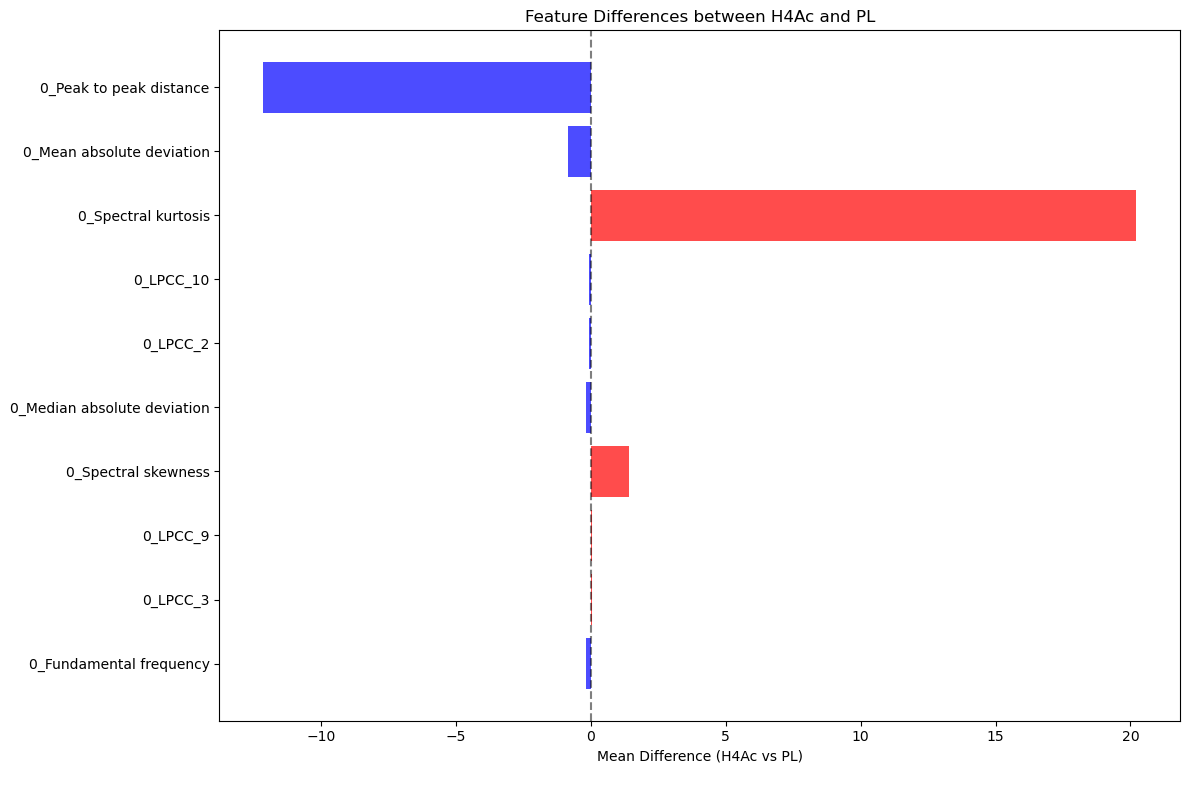

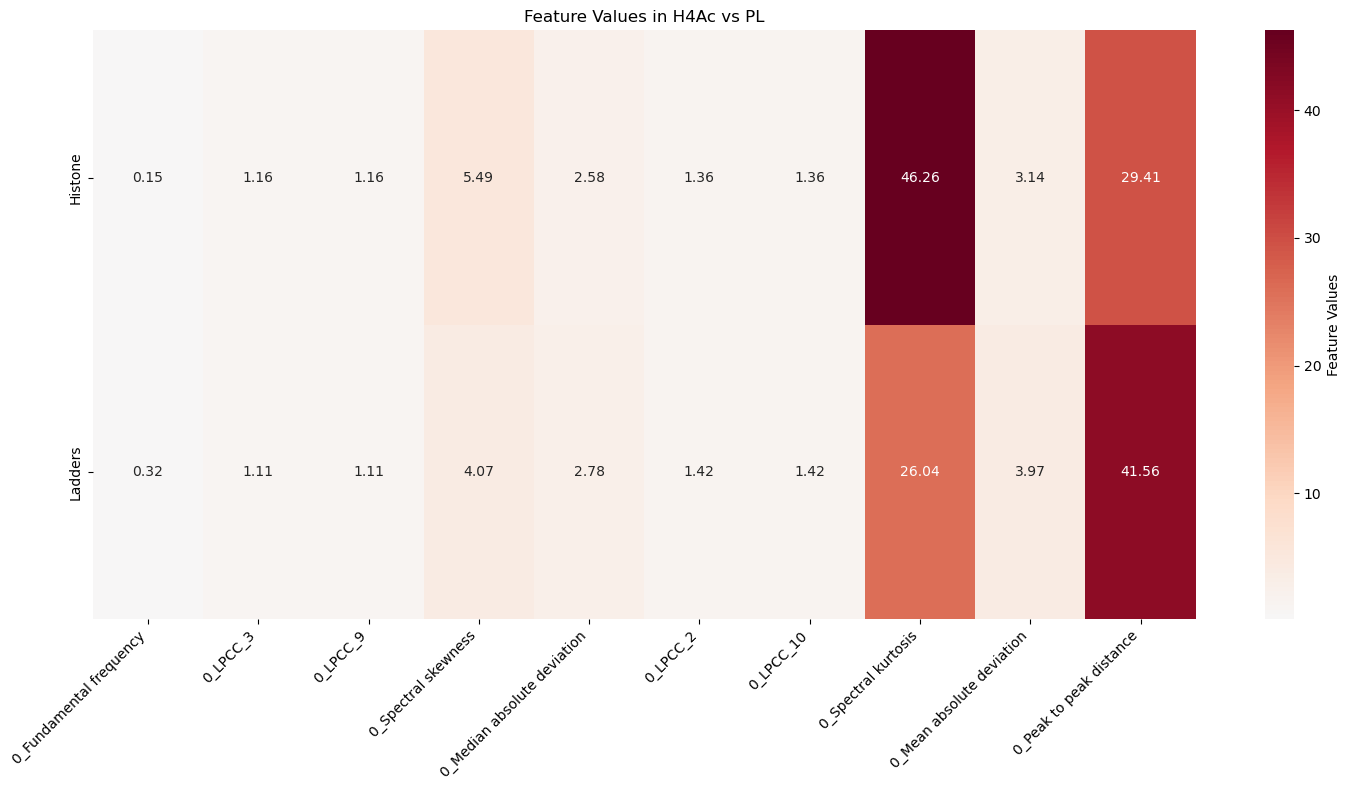

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Use original unscaled features for interpretation
features_original = features.values

# Define the clusters (0 -> Histone, 3 -> Ladders)
cluster_mapping = {0: "Histone", 3: "Ladders"}

# Analyze top features for comparison between Histone and Ladders
top_n = 10

# Select the top features based on weights
top_feature_indices = np.argsort(weights)[len(weights)//2 - 5 : len(weights)//2 + 5][::-1]

# Masks for h4ac (cluster 0) and Ladders (cluster 3)
histone_mask = labels == 0  # H4ac cluster
ladders_mask = labels == 3  # Ladders cluster
other_mask = labels != 0  # All other clusters except Histone

# Calculate the mean difference for each top feature between the 2
print("\n--- Comparing 'Histone' and 'Ladders' (Cluster 3)")

feature_differences = []
feature_names_list = []

for feat_idx in top_feature_indices:
    feat_name = feature_names[feat_idx] if feature_names is not None else f"Feature_{feat_idx}"
    
    # Calculate mean differences
    histone_mean = np.mean(features_original[histone_mask, feat_idx])
    ladders_mean = np.mean(features_original[ladders_mask, feat_idx])
    mean_diff = histone_mean - ladders_mean
    percent_diff = (mean_diff / ladders_mean) * 100 if ladders_mean != 0 else float('inf')
    
    # Statistical test (t-test) to check if the difference is significant
    t_stat, p_value = stats.ttest_ind(features_original[histone_mask, feat_idx], 
                                       features_original[ladders_mask, feat_idx], 
                                       equal_var=False)
    
    direction = "HIGHER in Histone" if mean_diff > 0 else "HIGHER in Ladders"
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    
    # If the feature difference is significant, append to list
    if p_value < 0.05: # arbitrary significance threshold
        feature_differences.append(mean_diff)
        feature_names_list.append(feat_name)
    
        print(f"{feat_name:<20} | Histone Mean: {histone_mean:8.3f} | Ladders Mean: {ladders_mean:8.3f} | "
              f"Diff: {mean_diff:8.3f} ({percent_diff:6.1f}%) {direction} {significance}")

# Plotting the feature differences between Histone and Ladders
plt.figure(figsize=(12, 8))

colors = ['red' if diff > 0 else 'blue' for diff in feature_differences]
plt.barh(feature_names_list, feature_differences, color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Mean Difference (H4Ac vs PL)\n')
plt.title('Feature Differences between H4Ac and PL')
plt.tight_layout()
plt.show()

# Heatmap for feature values between h4ac and Ladders
plt.figure(figsize=(15, 8))

# Get feature means for h4ac and Ladders clusters
cluster_means_original = [
    np.mean(features_original[histone_mask, feat_idx]) for feat_idx in top_feature_indices[:15]
] + [
    np.mean(features_original[ladders_mask, feat_idx]) for feat_idx in top_feature_indices[:15]
]

feat_names_original = [
    feature_names[idx] if feature_names is not None else f"Feature_{idx}" for idx in top_feature_indices[:15]
]

sns.heatmap([cluster_means_original[:len(top_feature_indices[:15])], 
             cluster_means_original[len(top_feature_indices[:15]):]], 
            xticklabels=feat_names_original, 
            yticklabels=["Histone", "Ladders"],
            cmap='RdBu_r', 
            center=0,
            annot=True, 
            fmt='.2f',
            cbar_kws={'label': 'Feature Values'})
plt.title('Feature Values in H4Ac vs PL')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
